In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer
from rocket_pams import rocket_sim
import numpy as np

In [8]:
rs = rocket_sim()  


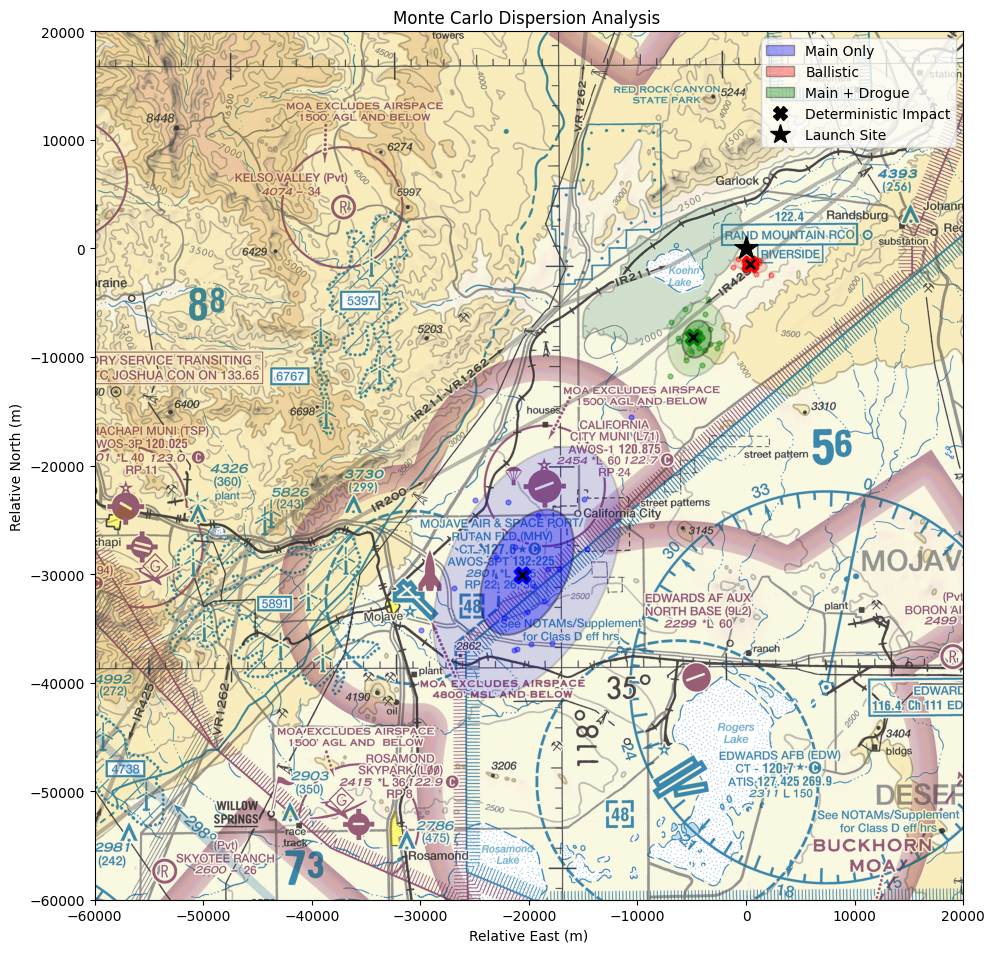

In [10]:


# ============================================
# DATASETS
# ============================================

datasets = {
    "Main Only": ("landing_dispersion_main_only.csv", "blue"),
    "Ballistic": ("landing_dispersion_ballistic.csv", "red"),
    "Main + Drogue": ("landing_dispersion_nominal.csv", "green"),
}

sectional_path = "Los Angeles SEC.tif"

# ============================================
# CREATE FIGURE
# ============================================

fig, ax = plt.subplots(figsize=(10,10))

# ============================================
# LOAD SECTIONAL MAP
# ============================================

with rasterio.open(sectional_path) as src:

    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    launch_x_abs, launch_y_abs = transformer.transform(rs.long, rs.lat)

    buffer = 80000  # big enough to cover manual limits

    min_x = launch_x_abs - buffer
    max_x = launch_x_abs + buffer
    min_y = launch_y_abs - buffer
    max_y = launch_y_abs + buffer

    window = from_bounds(min_x, min_y, max_x, max_y, src.transform)

    band = src.read(1, window=window)
    colormap = src.colormap(1)
    transform = src.window_transform(window)

# Convert palette → RGB
rgb = np.zeros((band.shape[0], band.shape[1], 3), dtype=np.uint8)
for key, value in colormap.items():
    rgb[band == key] = value[:3]

# Compute map extent
left = transform.c
top = transform.f
right = left + transform.a * band.shape[1]
bottom = top + transform.e * band.shape[0]
extent_abs = [left, right, bottom, top]

# Shift so launch = (0,0)
extent_rel = [
    extent_abs[0] - launch_x_abs,
    extent_abs[1] - launch_x_abs,
    extent_abs[2] - launch_y_abs,
    extent_abs[3] - launch_y_abs
]

ax.imshow(rgb, extent=extent_rel,alpha=0.8)

# ============================================
# PLOT DISPERSION CASES
# ============================================

for label, (file, color) in datasets.items():

    df = pd.read_csv(file)

    mc = df[df["type"] == "monte_carlo"]
    det = df[df["type"] == "deterministic"]

    impact_x = mc["impact_x_m"].values
    impact_y = mc["impact_y_m"].values

    det_x = det["impact_x_m"].values[0]
    det_y = det["impact_y_m"].values[0]

    # Monte Carlo cloud
    ax.scatter(
        impact_x,
        impact_y,
        s=12,
        color=color,
        alpha=0.4
    )

    # Deterministic landing (X marker)
    ax.scatter(
        det_x,
        det_y,
        s=120,
        marker="X",
        color="black",
        edgecolor=color,
        linewidth=2,
        zorder=6
    )

    # Covariance
    cov = np.cov(impact_x, impact_y)
    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    center_x = impact_x.mean()
    center_y = impact_y.mean()

    # 2σ ellipse (draw first)
    ellipse_2 = Ellipse(
        (center_x, center_y),
        4 * np.sqrt(vals[0]),
        4 * np.sqrt(vals[1]),
        angle=theta,
        facecolor=color,
        alpha=0.15,
        edgecolor="black",
        linewidth=1.5
    )

    # 1σ ellipse
    ellipse_1 = Ellipse(
        (center_x, center_y),
        2 * np.sqrt(vals[0]),
        2 * np.sqrt(vals[1]),
        angle=theta,
        facecolor=color,
        alpha=0.35,
        edgecolor="black",
        linewidth=1.5
    )

    ax.add_patch(ellipse_2)
    ax.add_patch(ellipse_1)

# ============================================
# LAUNCH SITE
# ============================================

ax.scatter(
    0, 0,
    s=300,
    marker="*",
    color="black",
    zorder=7
)

# ============================================
# MANUAL AXIS LIMITS
# ============================================

ax.set_xlim(-60000, 20000)
ax.set_ylim(-60000,20000)
ax.set_aspect("equal")

# ============================================
# CLEAN LEGEND
# ============================================

legend_elements = [

    Patch(facecolor="blue", alpha=0.35, edgecolor="black", label="Main Only"),
    Patch(facecolor="red", alpha=0.35, edgecolor="black", label="Ballistic"),
    Patch(facecolor="green", alpha=0.35, edgecolor="black", label="Main + Drogue"),

    Line2D([0], [0], marker='X', color='black', linestyle='None',
           markersize=10, label='Deterministic Impact'),

    Line2D([0], [0], marker='*', color='black', linestyle='None',
           markersize=15, label='Launch Site'),
]

ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

# ============================================
# FINAL LABELS
# ============================================

ax.set_xlabel("Relative East (m)")
ax.set_ylabel("Relative North (m)")
ax.set_title("Monte Carlo Dispersion Analysis ")

plt.tight_layout()
plt.show()